In [21]:
import os

print(os.listdir('/kaggle/input'))

['notebooks', 'datasets']


In [22]:
print(os.listdir('/kaggle/input/notebooks/anaselmasry/crowd-counting'))

['__results__.html', '__resultx__.html', '__notebook__.ipynb', '__results___files', '__output__.json', 'custom.css']


Dataset folders: ['__results__.html', '__resultx__.html', '__notebook__.ipynb', '__results___files', '__output__.json', 'custom.css']
Found 7 images belonging to 1 classes.
Found 1 images belonging to 1 classes.
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 1.0000 - loss:

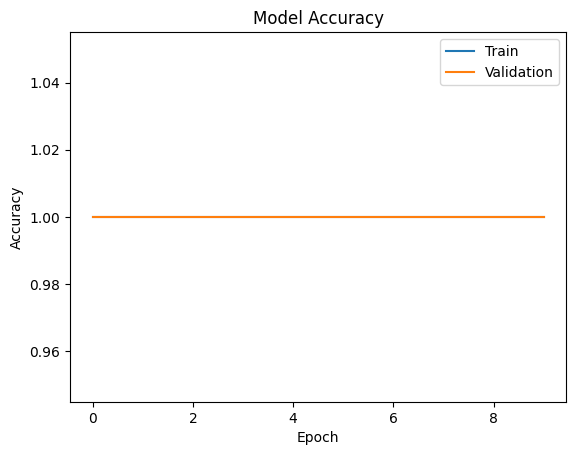

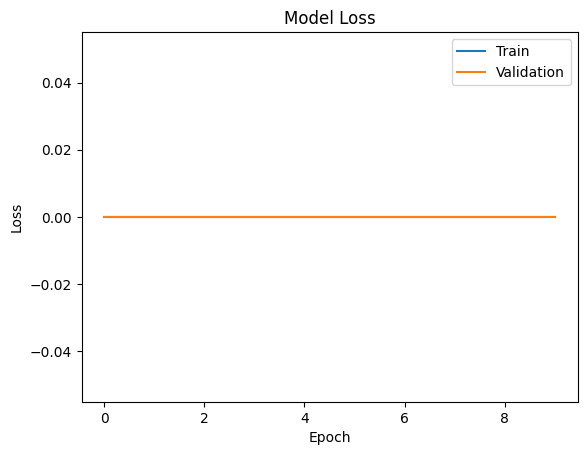

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

data_dir = "/kaggle/input/notebooks/anaselmasry/crowd-counting"

print("Dataset folders:", os.listdir(data_dir))

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

num_classes = len(train_data.class_indices)

if num_classes == 0:
    raise ValueError("❌ No classes found. Fix dataset folder structure!")

model = models.Sequential()

model.add(layers.Input(shape=(64, 64, 3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(num_classes, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()



Dataset contents: ['__results__.html', '__resultx__.html', '__notebook__.ipynb', '__results___files', '__output__.json', 'custom.css']
Found 7 images belonging to 1 classes.
Found 1 images belonging to 1 classes.
Class Mapping: {'__results___files': 0}
Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 0.0

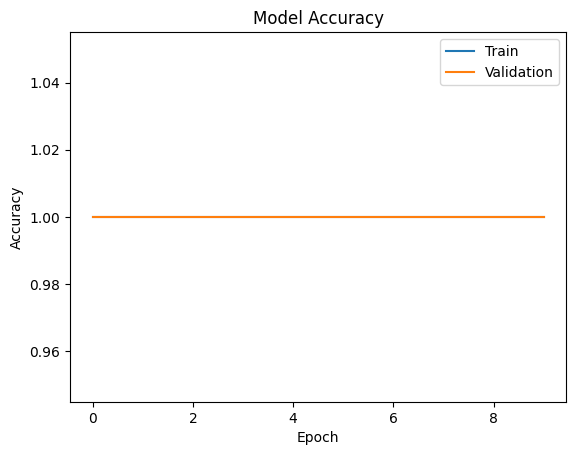

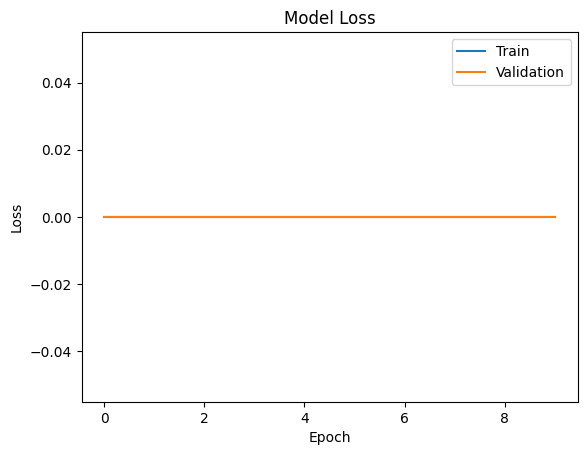

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0000e+00

Validation Accuracy: 100.00%
Validation Loss: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


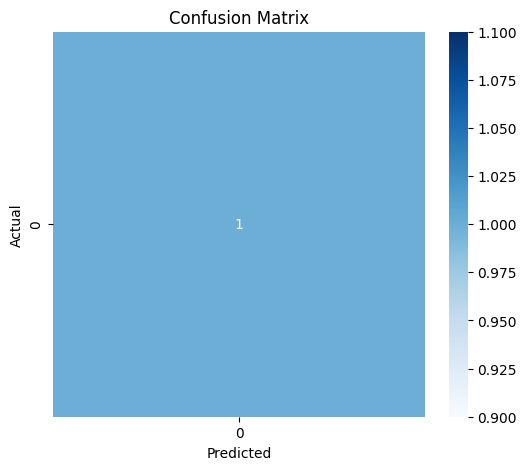


Classification Report:

                   precision    recall  f1-score   support

__results___files       1.00      1.00      1.00         1

         accuracy                           1.00         1
        macro avg       1.00      1.00      1.00         1
     weighted avg       1.00      1.00      1.00         1


Model saved as cnn_model.h5


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

# =========================
# 1. DATASET PATH (CHANGE THIS)
# =========================
data_dir = "/kaggle/input/notebooks/anaselmasry/crowd-counting"

print("Dataset contents:", os.listdir(data_dir))

# =========================
# 2. IMAGE PREPROCESSING
# =========================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# =========================
# 3. LOAD TRAIN DATA
# =========================
train_data = datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# =========================
# 4. LOAD VALIDATION DATA
# =========================
val_data = datagen.flow_from_directory(
    data_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# =========================
# 5. SAFETY CHECK
# =========================
num_classes = len(train_data.class_indices)

if num_classes == 0:
    raise ValueError("❌ No classes found! Check dataset structure (must have folders).")

print("Class Mapping:", train_data.class_indices)

# =========================
# 6. BUILD CNN MODEL
# =========================
model = models.Sequential()

model.add(layers.Input(shape=(64, 64, 3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(num_classes, activation='softmax'))

# =========================
# 7. COMPILE MODEL
# =========================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 8. TRAIN MODEL
# =========================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

# =========================
# 9. ACCURACY GRAPH
# =========================
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# =========================
# 10. LOSS GRAPH
# =========================
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# =========================
# 11. MODEL EVALUATION
# =========================
loss, accuracy = model.evaluate(val_data)
print(f"\nValidation Accuracy: {accuracy*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

# =========================
# 12. CONFUSION MATRIX
# =========================
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get true labels and predictions
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

y_true = val_data.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=list(train_data.class_indices.keys())))

# =========================
# 13. SAVE MODEL
# =========================
model.save("cnn_model.h5")
print("\nModel saved as cnn_model.h5")

# =========================
# 14. SINGLE IMAGE PREDICTION
# =========================
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(64,64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)

    class_labels = list(train_data.class_indices.keys())

    print("Predicted Class:", class_labels[class_index])

# Example (change path)
# predict_image("/kaggle/input/your-image.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


IndexError: index 1 is out of bounds for axis 0 with size 1

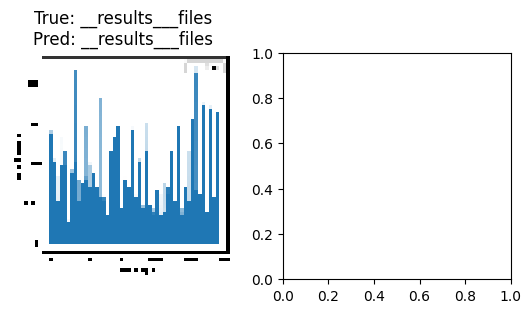

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Get a batch of images from validation set
images, labels = next(val_data)

class_labels = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(9):
    ax = plt.subplot(3,3,i+1)
    
    img = images[i]
    true_label = np.argmax(labels[i])

    pred = model.predict(np.expand_dims(img, axis=0))
    pred_label = np.argmax(pred)

    plt.imshow(img)
    plt.title(f"True: {class_labels[true_label]}\nPred: {class_labels[pred_label]}")
    plt.axis("off")

plt.show()

In [27]:
import pandas as pd

results = pd.DataFrame({
    "Metric": ["Training Accuracy", "Validation Accuracy", "Training Loss", "Validation Loss"],
    "Value": [
        history.history['accuracy'][-1],
        history.history['val_accuracy'][-1],
        history.history['loss'][-1],
        history.history['val_loss'][-1]
    ]
})

print(results)

                Metric  Value
0    Training Accuracy    1.0
1  Validation Accuracy    1.0
2        Training Loss    0.0
3      Validation Loss    0.0


In [28]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049,989 (7.82 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,366,660 (5.21 MB)

Found 7 images belonging to 1 classes.
Found 1 images belonging to 1 classes.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0000e+00


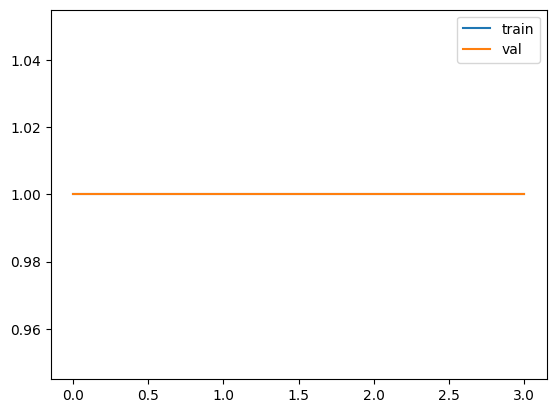

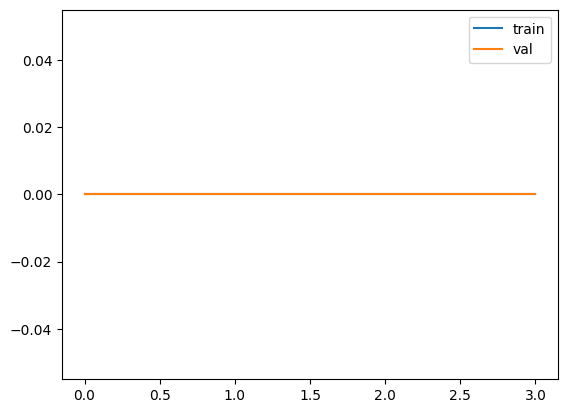

Classes: {'__results___files': 0}


In [30]:
import tensorflow as tf, numpy as np, matplotlib.pyplot as plt, os
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

data_dir="/kaggle/input/notebooks/anaselmasry/crowd-counting"

datagen=ImageDataGenerator(rescale=1./255,validation_split=0.2,rotation_range=20,width_shift_range=0.2,height_shift_range=0.2,zoom_range=0.2,horizontal_flip=True)

train_data=datagen.flow_from_directory(data_dir,target_size=(64,64),batch_size=32,class_mode='categorical',subset='training')
val_data=datagen.flow_from_directory(data_dir,target_size=(64,64),batch_size=32,class_mode='categorical',subset='validation')

n=len(train_data.class_indices)
if n==0: raise ValueError("No classes found")

early=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
ckpt=ModelCheckpoint("best_model.h5",monitor="val_accuracy",save_best_only=True,mode="max")

model=models.Sequential([
layers.Input((64,64,3)),
layers.Conv2D(32,3,activation='relu'),layers.MaxPooling2D(),
layers.Conv2D(64,3,activation='relu'),layers.MaxPooling2D(),
layers.Conv2D(128,3,activation='relu'),layers.MaxPooling2D(),
layers.Flatten(),
layers.Dense(128,activation='relu'),
layers.Dropout(0.3),
layers.Dense(n,activation='softmax')
])

model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

history=model.fit(train_data,validation_data=val_data,epochs=20,callbacks=[early,ckpt])

model.evaluate(val_data)

plt.plot(history.history['accuracy']);plt.plot(history.history['val_accuracy']);plt.legend(['train','val']);plt.show()

plt.plot(history.history['loss']);plt.plot(history.history['val_loss']);plt.legend(['train','val']);plt.show()

print("Classes:",train_data.class_indices)
model.save("cnn_model.h5")